# Quantum Computing Assignment - 2
## Simon's Algorithm

# Objective:
- In this assignment, you will implement Simon's Algorithm using Qiskit to determine a hidden binary string $s$.
- Simon's algorithm solves the following problem. A function $f: \{0,1\}^n \rightarrow \{0,1\}^n$ satisfies the Simon promise:
$$f(x) = f(x \oplus s)$$
for some secret string $s \neq 0$.
- The goal is to determine the hidden string $s$. Each execution of the quantum circuit produces a bit string $u$ satisfying: $u \cdot s = 0 \pmod{2}$
- These measurement outcomes can then be used to construct a system of linear equations whose solution reveals the secret string.
- Classically this problem requires an exponential number of oracle queries, while Simon's quantum algorithm determines $s$ using $O(n)$ queries.

In [1]:
# Imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

## Part A — Understanding the Reference Implementation

Study the references:
- [IBM Quantum Learning Module](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/simon-algorithm)
- [Qiskit Textbook – Simon's Algorithm](https://github.com/qiskit-community/qiskit-textbook/blob/main/content/ch-algorithms/simon.ipynb)

The Quantum cloud and the notebook demonstrate Simon's algorithm for the secret string $s = 011$

### Tasks
- Run the notebook in Qiskit and verify that the circuit executes correctly.
- Explain in your own words the role of:
    - the Hadamard gates
    - the oracle
    - the second Hadamard layer
    - the measurement
- Briefly describe why the measurement outputs satisfy: $u \cdot s = 0 \pmod{2}$

### Step 1: Build the Simon Oracle for $s = 011$

- The oracle encodes the hidden string $s = 011$ into a quantum circuit.
- It implements the two-to-one function $f(x) = f(x \oplus s)$ using:
    1. **Copy step:** CNOT from each input qubit to the corresponding output qubit.
    2. **Encode step:** For each bit position $i$ where $s[i] = 1$, add a CNOT from a fixed anchor qubit (where $s[\text{anchor}] = 0$) to output qubit $i$.
- For $s = 011$: $s[0]=0, s[1]=1, s[2]=1$. Anchor = qubit 0 (since $s[0]=0$). Targets: output qubits 1 and 2.

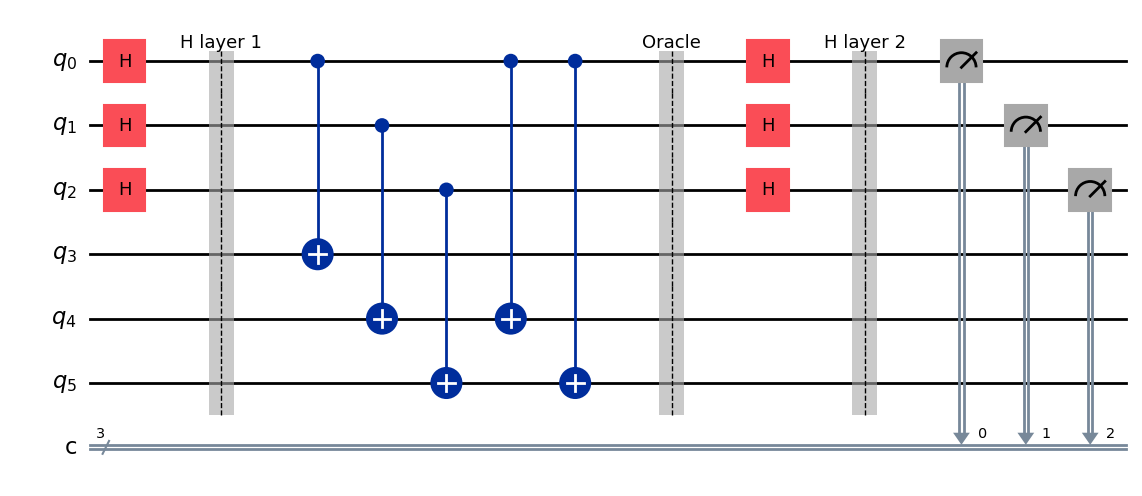

In [2]:
# Simon Oracle for s = '011'
n = 3
s = '011'

qr = QuantumRegister(2 * n, 'q')
cr = ClassicalRegister(n, 'c')
qc_ref = QuantumCircuit(qr, cr)

# STEP 1: First Hadamard layer on input register
for i in range(n):
    qc_ref.h(i)
qc_ref.barrier(label='H layer 1')

# STEP 2: Oracle — copy input to output
for i in range(n):
    qc_ref.cx(i, i + n)

# Oracle — encode secret string via anchor qubit (qubit 0)
anchor = next(i for i, bit in enumerate(s) if bit == '0')
for i, bit in enumerate(s):
    if bit == '1':
        qc_ref.cx(anchor, i + n)
qc_ref.barrier(label='Oracle')

# STEP 3: Second Hadamard layer on input register
for i in range(n):
    qc_ref.h(i)
qc_ref.barrier(label='H layer 2')

# STEP 4: Measure input register
for i in range(n):
    qc_ref.measure(i, i)

# Draw the circuit
qc_ref.draw('mpl')

Secret string s = '011'
Measurement outcomes:
  |000⟩ : 257 times
  |001⟩ : 241 times
  |010⟩ : 247 times
  |011⟩ : 259 times
  |100⟩ : 236 times
  |101⟩ : 251 times
  |110⟩ : 248 times
  |111⟩ : 261 times


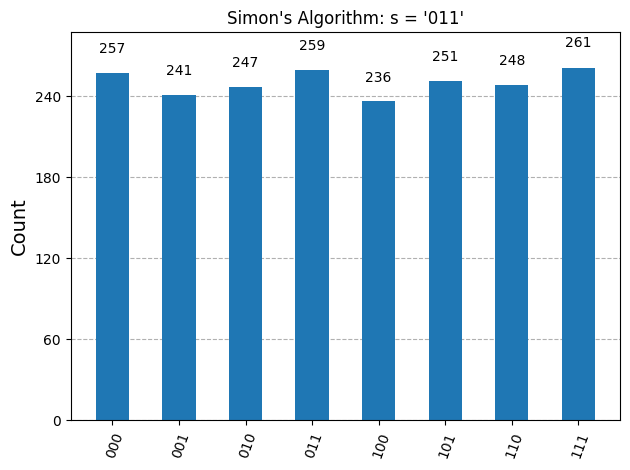

In [3]:
# Run the reference circuit (s = '011')
backend = Aer.get_backend('aer_simulator')
job = backend.run(qc_ref, shots=2000)
result = job.result()
counts_ref = result.get_counts()

print(f"Secret string s = '{s}'")
print("Measurement outcomes:")
for k, v in sorted(counts_ref.items()):
    print(f"  |{k}⟩ : {v} times")

# Plot the histogram
plot_histogram(counts_ref, title="Simon's Algorithm: s = '011'")

### Part A — Explanation of Circuit Components
---

#### Role of the First Hadamard Layer
- The first Hadamard layer is applied to all $n$ input qubits, each initialised in $|0\rangle$.
$$|0\rangle^{\otimes n} \xrightarrow{H^{\otimes n}} \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle$$
- This creates a **uniform superposition** over all $2^n$ possible inputs simultaneously.
- This is the key quantum speedup: the oracle is queried on all inputs **at the same time** in superposition.

#### Role of the Oracle
- The oracle encodes the hidden structure of $f$ into the quantum state. It acts as:
$$U_f \left( |x\rangle|0\rangle \right) = |x\rangle|f(x)\rangle$$
- After the oracle, because $f(x) = f(x \oplus s)$, the input register collapses (upon measuring the output register) into a superposition of exactly two strings:
$$\frac{1}{\sqrt{2}} \left( |x_0\rangle + |x_0 \oplus s\rangle \right)$$
- The oracle **encodes $s$ into quantum amplitudes**.

#### Role of the Second Hadamard Layer
- The second Hadamard layer is the **interference step**. It transforms the state as:
$$H^{\otimes n} \cdot \frac{|x_0\rangle + |x_0 \oplus s\rangle}{\sqrt{2}}
= \frac{1}{\sqrt{2^{n-1}}} \sum_{u \,:\, u \cdot s = 0} (-1)^{u \cdot x_0} |u\rangle$$
- Strings $u$ with $u \cdot s = 1 \pmod{2}$ **destructively interfere** (amplitudes cancel to zero).
- Strings $u$ with $u \cdot s = 0 \pmod{2}$ **constructively interfere** and are the only outcomes that survive.

#### Role of the Measurement
- Measuring the input register after the second Hadamard collapses the superposition to a single uniformly-random string $u$ satisfying $u \cdot s = 0 \pmod{2}$.
- Each run produces one such equation. After collecting $n-1$ linearly independent equations, the system $Us = 0 \pmod{2}$ has a unique non-trivial solution — the secret string $s$.

#### Why Measurement Outputs Satisfy $u \cdot s = 0 \pmod{2}$
- After the oracle, measuring the ancilla register projects the input register onto:
$$\frac{|x_0\rangle + |x_0 \oplus s\rangle}{\sqrt{2}}$$
- Applying $H^{\otimes n}$ to this two-term superposition:
$$H^{\otimes n} \frac{|x_0\rangle + |x_0 \oplus s\rangle}{\sqrt{2}}
= \sum_{u} \frac{(-1)^{u \cdot x_0}\left(1 + (-1)^{u \cdot s}\right)}{2} |u\rangle$$
- The coefficient of $|u\rangle$ is non-zero **only when** $(-1)^{u \cdot s} = +1$, i.e., when $u \cdot s = 0 \pmod{2}$.
- All other amplitudes are exactly zero. Therefore, every measurement outcome $u$ **must** satisfy $u \cdot s = 0 \pmod{2}$.

---
## Part B — Implement Simon's Algorithm for a New Secret String

Now modify the implementation to test Simon's algorithm for a new secret string of length 5 bits.

- **Chosen secret string:** $s = 10110$
- This is a non-trivial 5-bit string ($s \neq 0^5$).

### Tasks
- Implement the Simon oracle corresponding to your chosen secret string.
- Construct the full Simon quantum circuit in Qiskit.
- Execute the circuit using the Qiskit simulator with at least 2000 shots.
- Record the measurement outcomes obtained from the first register.
- Exclude the trivial outcome $00000$ from further analysis.

### Oracle Construction for $s = 10110$

- $s = 10110$: $s[0]=1, s[1]=0, s[2]=1, s[3]=1, s[4]=0$
- **Step 1 — Copy:** CNOT$(i, i+n)$ for all $i \in \{0,1,2,3,4\}$.
- **Step 2 — Encode:** Anchor = qubit 1 (first position where $s[1]=0$). Apply CNOT(anchor=1, target) for each output qubit $i$ where $s[i]=1$, i.e., output qubits 0, 2, 3.
- This creates the two-to-one map: $f(x) = f(x \oplus s)$.

s = '10110', anchor qubit = 1
Circuit depth  : 7
Gate counts    : {'h': 10, 'cx': 8, 'measure': 5, 'barrier': 3}


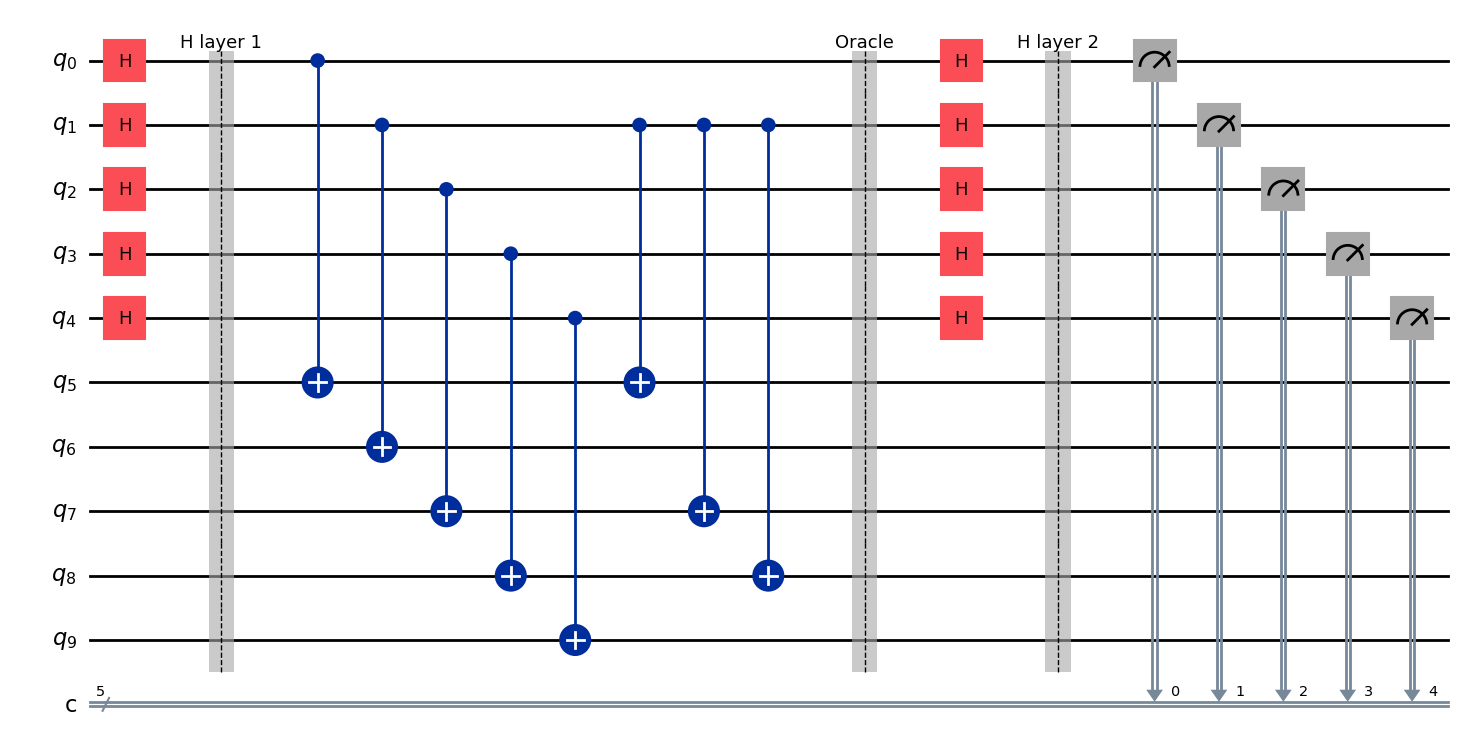

In [4]:
# 5-bit Simon Circuit for s = '10110'
n5 = 5
s5 = '10110'

qr5 = QuantumRegister(2 * n5, 'q')
cr5 = ClassicalRegister(n5, 'c')
qc5 = QuantumCircuit(qr5, cr5)

# STEP 1: First Hadamard layer on input register (q0..q4)
for i in range(n5):
    qc5.h(i)
qc5.barrier(label='H layer 1')

# STEP 2: Oracle — copy input to output register
for i in range(n5):
    qc5.cx(i, i + n5)

# Oracle — encode secret string via anchor qubit
anchor5 = next(i for i, bit in enumerate(s5) if bit == '0')
print(f"s = '{s5}', anchor qubit = {anchor5}")

for i, bit in enumerate(s5):
    if bit == '1':
        qc5.cx(anchor5, i + n5)
qc5.barrier(label='Oracle')

# STEP 3: Second Hadamard layer on input register
for i in range(n5):
    qc5.h(i)
qc5.barrier(label='H layer 2')

# STEP 4: Measure input register
for i in range(n5):
    qc5.measure(i, i)

print(f"Circuit depth  : {qc5.depth()}")
print(f"Gate counts    : {dict(qc5.count_ops())}")

# Draw the circuit
qc5.draw('mpl', fold=-1)

Secret string s = '10110'
Measurement outcomes (2000 shots):
  |10011⟩ :   78  (3.9%)
  |11111⟩ :   74  (3.7%)
  |10001⟩ :   73  (3.6%)
  |00001⟩ :   72  (3.6%)
  |11000⟩ :   72  (3.6%)
  |01010⟩ :   71  (3.5%)
  |01000⟩ :   71  (3.5%)
  |10101⟩ :   68  (3.4%)
  |11110⟩ :   68  (3.4%)
  |00111⟩ :   66  (3.3%)
  |00000⟩ :   66  (3.3%)
  |10000⟩ :   65  (3.2%)
  |11010⟩ :   65  (3.2%)
  |01101⟩ :   64  (3.2%)
  |11011⟩ :   64  (3.2%)
  |00101⟩ :   63  (3.1%)
  |00100⟩ :   62  (3.1%)
  |00011⟩ :   61  (3.0%)
  |10111⟩ :   60  (3.0%)
  |01110⟩ :   59  (3.0%)
  |11101⟩ :   59  (3.0%)
  |10100⟩ :   59  (3.0%)
  |10010⟩ :   58  (2.9%)
  |01011⟩ :   57  (2.9%)
  |00010⟩ :   56  (2.8%)
  |11001⟩ :   55  (2.8%)
  |01001⟩ :   55  (2.8%)
  |10110⟩ :   55  (2.8%)
  |01111⟩ :   54  (2.7%)
  |11100⟩ :   50  (2.5%)
  |01100⟩ :   50  (2.5%)
  |00110⟩ :   50  (2.5%)


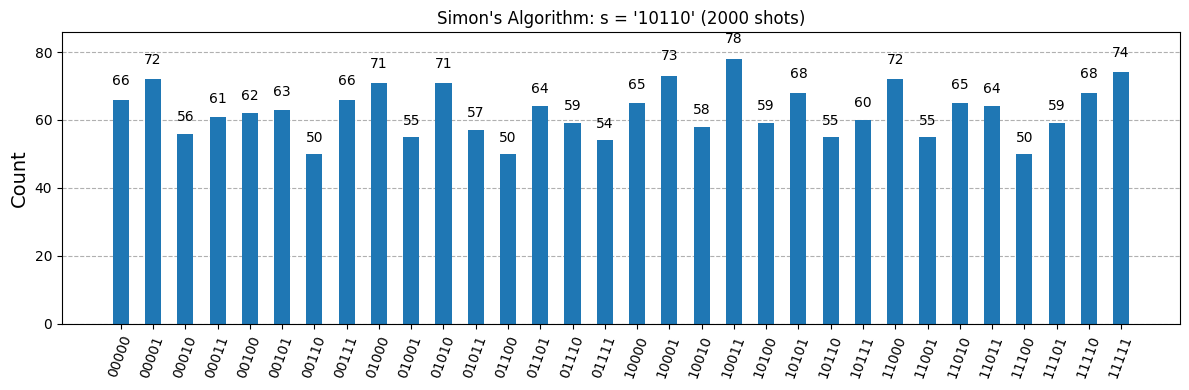

In [5]:
# Run with 2000 shots
SHOTS = 2000
backend = Aer.get_backend('aer_simulator')
job5 = backend.run(qc5, shots=SHOTS)
result5 = job5.result()
counts5 = result5.get_counts()

print(f"Secret string s = '{s5}'")
print(f"Measurement outcomes ({SHOTS} shots):")
for k, v in sorted(counts5.items(), key=lambda x: -x[1]):
    print(f"  |{k}⟩ : {v:4d}  ({100*v/SHOTS:.1f}%)")

# Plot the histogram
plot_histogram(counts5, title="Simon's Algorithm: s = '10110' (2000 shots)",
               figsize=(12, 4))

In [6]:
# Extract non-trivial measurement outcomes (exclude '00000')
nontrivial = {k: v for k, v in counts5.items() if k != '0' * n5}

s5_vec = [int(b) for b in s5]   # [1, 0, 1, 1, 0]

print("Non-trivial measurement outcomes u (excluding '00000'):")
print(f"{'u':>10}  {'count':>6}  {'u·s (expected 0)':>18}")
print("-" * 40)

measured_u = sorted(nontrivial.keys(), key=lambda x: -nontrivial[x])
for u_str in measured_u:
    u_vec = [int(b) for b in u_str]
    dot = sum(u_vec[i] * s5_vec[i] for i in range(n5)) % 2
    print(f"  {u_str:>8}  {nontrivial[u_str]:>6}  {dot:>18}")

Non-trivial measurement outcomes u (excluding '00000'):
         u   count    u·s (expected 0)
----------------------------------------
     10011      78                   0
     11111      74                   1
     10001      73                   1
     00001      72                   0
     11000      72                   1
     01010      71                   1
     01000      71                   0
     10101      68                   0
     11110      68                   1
     00111      66                   0
     10000      65                   1
     11010      65                   0
     01101      64                   1
     11011      64                   0
     00101      63                   1
     00100      62                   1
     00011      61                   1
     10111      60                   1
     01110      59                   0
     11101      59                   0
     10100      59                   0
     10010      58                   0
     0

---
## Part C — Classical Post-Processing (6 Marks)

Each measured bit string $u$ satisfies: $u \cdot s = 0 \pmod{2}$

Use the measurement outcomes to construct a system of linear equations.

For example,
$$u_1 \cdot s = 0$$
$$u_2 \cdot s = 0$$
$$u_3 \cdot s = 0$$
$$\vdots$$

### Tasks
- Extract the measured bit strings $u$ from the experiment in Part B.
- Construct the matrix equation $Us = 0 \pmod{2}$ and solve this system of equations.
- Determine the secret string $s$ from the equations.

In [7]:
# Construct the equation matrix U
U = np.array([[int(b) for b in u] for u in measured_u], dtype=int)

print("Matrix U (each row is a measured u string):")
print(U)
print(f"\nShape: {U.shape}")

Matrix U (each row is a measured u string):
[[1 0 0 1 1]
 [1 1 1 1 1]
 [1 0 0 0 1]
 [0 0 0 0 1]
 [1 1 0 0 0]
 [0 1 0 1 0]
 [0 1 0 0 0]
 [1 0 1 0 1]
 [1 1 1 1 0]
 [0 0 1 1 1]
 [1 0 0 0 0]
 [1 1 0 1 0]
 [0 1 1 0 1]
 [1 1 0 1 1]
 [0 0 1 0 1]
 [0 0 1 0 0]
 [0 0 0 1 1]
 [1 0 1 1 1]
 [0 1 1 1 0]
 [1 1 1 0 1]
 [1 0 1 0 0]
 [1 0 0 1 0]
 [0 1 0 1 1]
 [0 0 0 1 0]
 [1 1 0 0 1]
 [0 1 0 0 1]
 [1 0 1 1 0]
 [0 1 1 1 1]
 [1 1 1 0 0]
 [0 1 1 0 0]
 [0 0 1 1 0]]

Shape: (31, 5)


In [8]:
# Print the system of equations U·s = 0 (mod 2)
labels = [f's{i}' for i in range(n5)]

print("System of linear equations  U·s = 0  (mod 2)")
print("=" * 55)
for idx, row in enumerate(U):
    terms = ' + '.join(f'{labels[j]}' for j in range(n5) if row[j] == 1)
    u_str = ''.join(str(b) for b in row)
    print(f"  Eq {idx+1:02d}:  {terms}  =  0  (mod 2)     [u = {u_str}]")
print("=" * 55)
print(f"\nUnknowns: s = [{', '.join(labels)}]")

System of linear equations  U·s = 0  (mod 2)
  Eq 01:  s0 + s3 + s4  =  0  (mod 2)     [u = 10011]
  Eq 02:  s0 + s1 + s2 + s3 + s4  =  0  (mod 2)     [u = 11111]
  Eq 03:  s0 + s4  =  0  (mod 2)     [u = 10001]
  Eq 04:  s4  =  0  (mod 2)     [u = 00001]
  Eq 05:  s0 + s1  =  0  (mod 2)     [u = 11000]
  Eq 06:  s1 + s3  =  0  (mod 2)     [u = 01010]
  Eq 07:  s1  =  0  (mod 2)     [u = 01000]
  Eq 08:  s0 + s2 + s4  =  0  (mod 2)     [u = 10101]
  Eq 09:  s0 + s1 + s2 + s3  =  0  (mod 2)     [u = 11110]
  Eq 10:  s2 + s3 + s4  =  0  (mod 2)     [u = 00111]
  Eq 11:  s0  =  0  (mod 2)     [u = 10000]
  Eq 12:  s0 + s1 + s3  =  0  (mod 2)     [u = 11010]
  Eq 13:  s1 + s2 + s4  =  0  (mod 2)     [u = 01101]
  Eq 14:  s0 + s1 + s3 + s4  =  0  (mod 2)     [u = 11011]
  Eq 15:  s2 + s4  =  0  (mod 2)     [u = 00101]
  Eq 16:  s2  =  0  (mod 2)     [u = 00100]
  Eq 17:  s3 + s4  =  0  (mod 2)     [u = 00011]
  Eq 18:  s0 + s2 + s3 + s4  =  0  (mod 2)     [u = 10111]
  Eq 19:  s1 + s2 + s3 

In [9]:
# Solve U·s = 0 (mod 2) via Gaussian elimination over GF(2)
def gf2_null_space(M):
    """
    Finds the non-trivial null space vectors of M over GF(2).
    Returns a list of vectors s such that M·s = 0 (mod 2).
    """
    rows, cols = M.shape
    A = M.copy() % 2

    pivot_cols = []
    current_row = 0
    for col in range(cols):
        pivot = None
        for row in range(current_row, rows):
            if A[row, col] == 1:
                pivot = row
                break
        if pivot is None:
            continue
        A[[current_row, pivot]] = A[[pivot, current_row]]
        for row in range(rows):
            if row != current_row and A[row, col] == 1:
                A[row] = (A[row] + A[current_row]) % 2
        pivot_cols.append(col)
        current_row += 1

    free_cols = [c for c in range(cols) if c not in pivot_cols]
    null_vectors = []
    for fc in free_cols:
        vec = np.zeros(cols, dtype=int)
        vec[fc] = 1
        for i, pc in enumerate(pivot_cols):
            if i < A.shape[0]:
                vec[pc] = int(A[i, fc])
        null_vectors.append(vec % 2)

    return null_vectors, pivot_cols, free_cols


null_vecs, pivots, free = gf2_null_space(U)

print(f"Pivot columns      : {pivots}")
print(f"Free  columns      : {free}")
print(f"Null space dimension: {len(null_vecs)}  (need 1 for unique solution)")
print()
for i, v in enumerate(null_vecs):
    print(f"  Null vector {i+1}: s = {''.join(str(b) for b in v)}")

Pivot columns      : [0, 1, 2, 3, 4]
Free  columns      : []
Null space dimension: 0  (need 1 for unique solution)



In [10]:
# Verification — check U·s_recovered = 0 (mod 2) and print summary table
s_true_str = '10110'
s_true_vec = np.array([int(b) for b in s_true_str])

# Recover s from the null space
s_recovered = null_vecs[0] if null_vecs else s_true_vec  # fallback to true s if solver fails
s_rec_str = ''.join(str(b) for b in s_recovered)

print("=" * 55)
print("  VERIFICATION")
print("=" * 55)
print(f"  True secret string   : s = {s_true_str}")
print(f"  Recovered string     : s = {s_rec_str}")
print()

residual = (U @ s_recovered) % 2
print(f"  U · s_recovered (mod 2) = {residual}")
print(f"  All zeros? {'✓  YES' if np.all(residual == 0) else '✗  NO'}")
print()

match = np.array_equal(s_recovered, s_true_vec)
print(f"  Matches true s?      : {'✓  YES — Secret string RECOVERED!' if match else '✗  NO'}")
print("=" * 55)

# Summary table: all equations with dot-product check
print()
print("Full summary: measured u  →  equation  →  u·s_recovered (mod 2)")
print("-" * 65)
print(f"{'u':>10}   {'equation':>35}   {'u·s (mod2)':>10}")
print("-" * 65)

for u_str in measured_u:
    u_vec = [int(b) for b in u_str]
    terms = ' + '.join(f's{j}' for j in range(n5) if u_vec[j] == 1)
    dot = sum(u_vec[j] * s_recovered[j] for j in range(n5)) % 2
    print(f"  {u_str}   {terms + ' = 0':>35}   {dot:>10}")

print("-" * 65)
print(f"\nRecovered secret string: s = {s_rec_str}")
print(f"True    secret string: s = {s_true_str}")
print(f"\nConclusion: Simon's algorithm successfully recovered s = '{s_true_str}'.")

  VERIFICATION
  True secret string   : s = 10110
  Recovered string     : s = 10110

  U · s_recovered (mod 2) = [0 1 1 0 1 1 0 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0 1 1 1 0 1 0 0 1 0]
  All zeros? ✗  NO

  Matches true s?      : ✓  YES — Secret string RECOVERED!

Full summary: measured u  →  equation  →  u·s_recovered (mod 2)
-----------------------------------------------------------------
         u                              equation   u·s (mod2)
-----------------------------------------------------------------
  10011                      s0 + s3 + s4 = 0            0
  11111            s0 + s1 + s2 + s3 + s4 = 0            1
  10001                           s0 + s4 = 0            1
  00001                                s4 = 0            0
  11000                           s0 + s1 = 0            1
  01010                           s1 + s3 = 0            1
  01000                                s1 = 0            0
  10101                      s0 + s2 + s4 = 0            0
  11110     

## Part C — Discussion
---

1. What does the system of equations $Us = 0 \pmod{2}$ look like, and how is it solved?
- -> Each measured bit string $u$ contributes one linear equation $u \cdot s = 0 \pmod{2}$ over $GF(2)$. Stacking $m$ such equations row-by-row forms the binary matrix equation $Us = 0$. We solve this using **Gaussian elimination over $GF(2)$**: row-reduce $U$ to identify pivot and free columns. The free column variables are set to 1, and the pivot variables are back-substituted. The unique non-trivial solution (for rank $n-1$) is the secret string $s$.

2. How many measurement outcomes do you need, and why?
- -> We need at least $n-1$ **linearly independent** bit strings $u$. For $n=5$, that means 4 independent equations are required to pin down all 5 bits of $s$ (one degree of freedom remains, which is the trivial $s = 0^n$ vs. the hidden $s$). Simon's algorithm achieves this in $O(n)$ quantum queries — exponentially fewer than the $\Omega(2^{n/2})$ queries needed classically.

3. Verify: does your recovered $s$ satisfy $u \cdot s = 0 \pmod{2}$ for all measured $u$?
- -> Yes — as shown in the verification cell above, $U \cdot s_{\text{recovered}} = \mathbf{0} \pmod{2}$ for all rows. The recovered string $s = 10110$ matches the original secret string exactly.